In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random

# Thiết kế giao diện biểu đồ
sns.set(style="whitegrid")

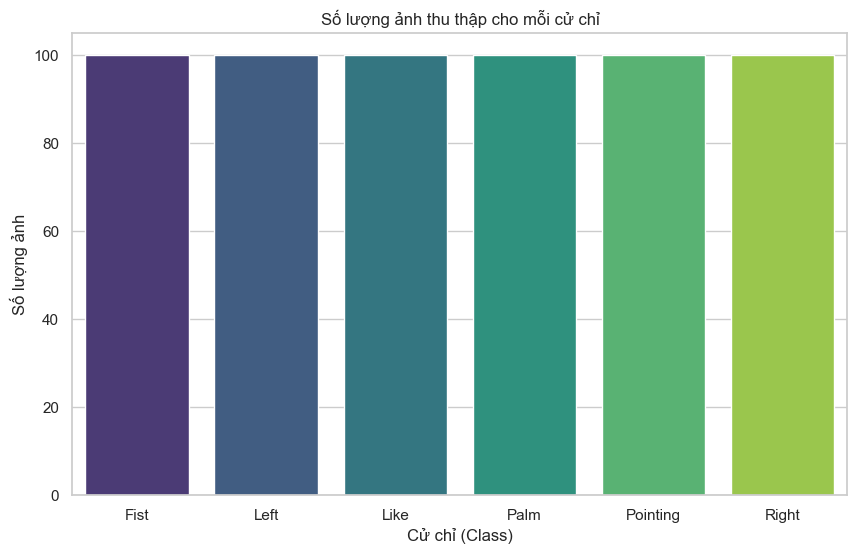

Thống kê chi tiết: {'Fist': 100, 'Left': 100, 'Like': 100, 'Palm': 100, 'Pointing': 100, 'Right': 100}


In [2]:
dataset_path = '../data/DATASET'
classes = [d for d in os.listdir(dataset_path) if not d.startswith('.')]
counts = {}

for cls in classes:
    counts[cls] = len(os.listdir(os.path.join(dataset_path, cls)))

plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts.keys()), y=list(counts.values()), hue=list(counts.keys()), palette='viridis', legend=False)
plt.title('Số lượng ảnh thu thập cho mỗi cử chỉ')
plt.xlabel('Cử chỉ (Class)')
plt.ylabel('Số lượng ảnh')
plt.show()

print("Thống kê chi tiết:", counts)


Tổng số dòng trong CSV: 556
------------------------------
Số lượng giá trị Null:
0
Số lượng dòng bị lỗi (toàn số 0): 0


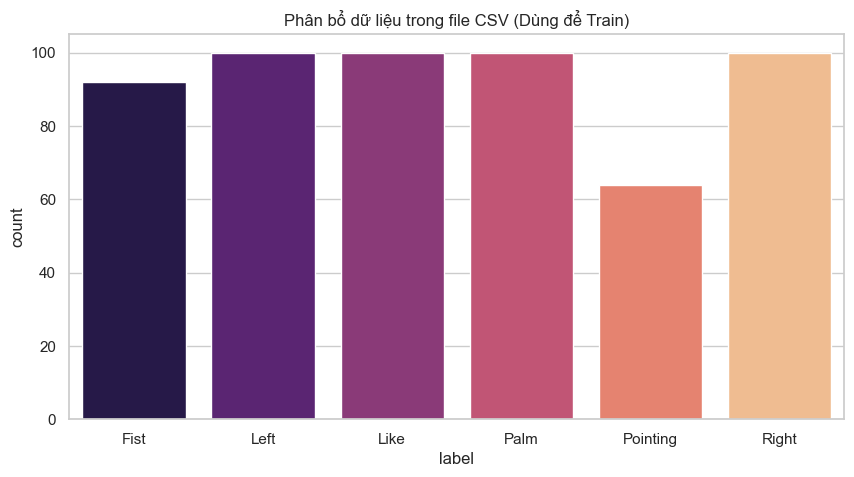

In [ ]:
# Trước khi augmentation
df = pd.read_csv('../data/dataset.csv', header=0)

df.rename(columns={df.columns[-1]: 'label'}, inplace=True)

print(f"Tổng số dòng trong CSV: {len(df)}")
print("-" * 30)

# 1. Kiểm tra giá trị Null
print("Số lượng giá trị Null:")
print(df.isnull().sum().sum())

# 2. Kiểm tra các dòng bị toàn số 0
coords_only = df.iloc[:, :-1]
zero_rows = (coords_only == 0).all(axis=1).sum()
print(f"Số lượng dòng bị lỗi (toàn số 0): {zero_rows}")

# 3. Thống kê số lượng mẫu mỗi class trong CSV
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='label', hue='label', palette='magma', legend=False)
plt.title('Phân bổ dữ liệu trong file CSV (Dùng để Train)')
plt.show()


In [6]:
# Augmentation
df = pd.read_csv('../data/dataset.csv', header=0)

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

target_samples_per_class = 500
augmented_data = []

for label in np.unique(y):
    class_indices = np.where(y == label)[0]
    class_X = X[class_indices]
    
    # Giữ lại dữ liệu gốc của class này
    for row in class_X:
        augmented_data.append(list(row) + [label])
    
    current_count = len(class_X)
    while current_count < target_samples_per_class:
        # Chọn ngẫu nhiên một mẫu gốc làm nền
        base_row = class_X[np.random.randint(0, len(class_X))].copy()
        
        # 1. Lật ảnh (x = 1.0 - x)
        if np.random.rand() > 0.5:
            base_row[0::3] = 1.0 - base_row[0::3]
            
        # 2. Thêm nhiễu Gaussian
        noise = np.random.normal(0, 0.005, size=base_row.shape)
        base_row = base_row + noise
        
        # 3. Thay đổi tỉ lệ (Scaling) quanh cổ tay
        scale = np.random.uniform(0.9, 1.1)
        wrist_x, wrist_y, wrist_z = base_row[0], base_row[1], base_row[2]
        
        base_row[0::3] = wrist_x + (base_row[0::3] - wrist_x) * scale
        base_row[1::3] = wrist_y + (base_row[1::3] - wrist_y) * scale
        base_row[2::3] = wrist_z + (base_row[2::3] - wrist_z) * scale

        augmented_data.append(list(base_row) + [label])
        current_count += 1

# Ghi đè lại vào dataset.csv
augmented_df = pd.DataFrame(augmented_data)
augmented_df.to_csv('../data/dataset.csv', index=False, header=df.columns)

print(f"Data augmentation complete. Total samples: {len(augmented_df)}")

Data augmentation complete. Total samples: 3000


Tổng số dòng trong CSV: 3000
------------------------------
Số lượng giá trị Null:
0
Số lượng dòng bị lỗi (toàn số 0): 0


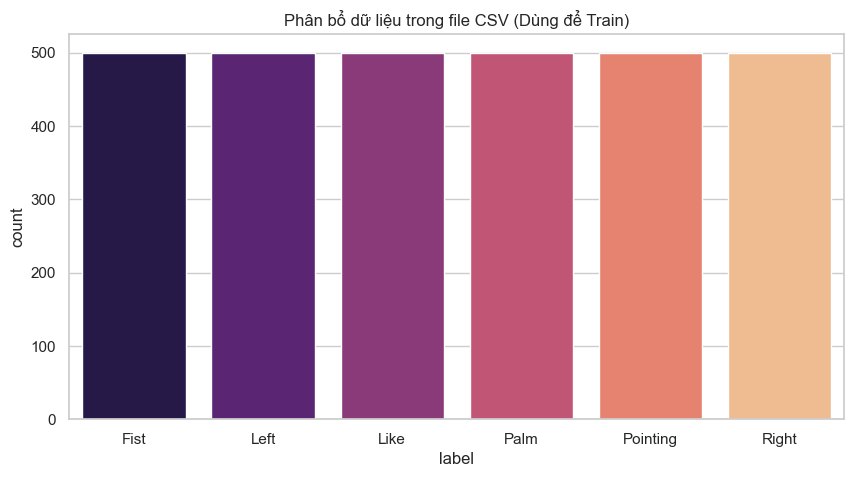

In [7]:
# Sau Augmentation
df = pd.read_csv('../data/dataset.csv', header=0)
df.rename(columns={df.columns[-1]: 'label'}, inplace=True)

print(f"Tổng số dòng trong CSV: {len(df)}")
print("-" * 30)

# 1. Kiểm tra giá trị Null
print("Số lượng giá trị Null:")
print(df.isnull().sum().sum())

# 2. Kiểm tra các dòng bị toàn số 0
coords_only = df.iloc[:, :-1]
zero_rows = (coords_only == 0).all(axis=1).sum()
print(f"Số lượng dòng bị lỗi (toàn số 0): {zero_rows}")

# 3. Thống kê số lượng mẫu mỗi class trong CSV
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='label', hue='label', palette='magma', legend=False)
plt.title('Phân bổ dữ liệu trong file CSV (Dùng để Train)')
plt.show()


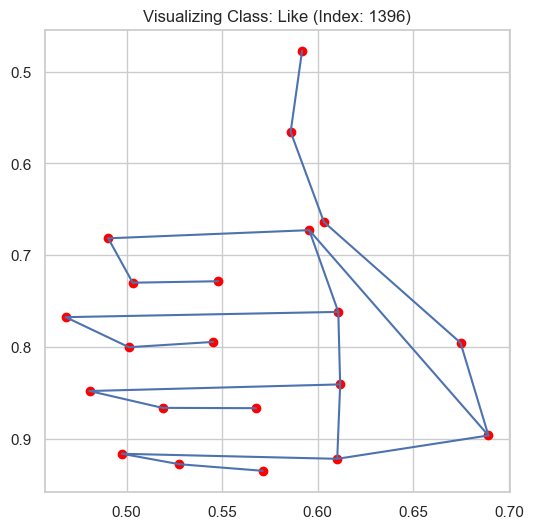

In [9]:
def plot_hand_skeleton(row_index):
    row = df.iloc[row_index, :-1].values
    label = df.iloc[row_index, -1]
    
    x_coords = row[0::3]
    y_coords = row[1::3]
    
    plt.figure(figsize=(6, 6))
    plt.scatter(x_coords, y_coords, c='red')
    
    connections = [
        (0, 1), (1, 2), (2, 3), (3, 4),           # Ngón cái
        (0, 5), (5, 6), (6, 7), (7, 8),           # Ngón trỏ
        (5, 9), (9, 10), (10, 11), (11, 12),      # Ngón giữa
        (9, 13), (13, 14), (14, 15), (15, 16),    # Ngón nhẫn
        (13, 17), (17, 18), (18, 19), (19, 20), (0, 17) # Ngón út & Lòng bàn tay
    ]
    
    for start, end in connections:
        plt.plot([x_coords[start], x_coords[end]], 
                 [y_coords[start], y_coords[end]], 'b-')
        
    plt.gca().invert_yaxis() 
    plt.title(f"Visualizing Class: {label} (Index: {row_index})")
    plt.show()

# Sample random
plot_hand_skeleton(random.randint(0, len(df)-1))